# ASSIGNMENT 4: Linear and logistic regression

## Business understanding (Sandra)

## Data understanding (Anni)

In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
real_estate_valuation = fetch_ucirepo(id=477) 
  
# data (as pandas dataframes) 
X = real_estate_valuation.data.features 
y = real_estate_valuation.data.targets['Y house price of unit area']

In [2]:
X

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245
...,...,...,...,...,...,...
409,2013.000,13.7,4082.01500,0,24.94155,121.50381
410,2012.667,5.6,90.45606,9,24.97433,121.54310
411,2013.250,18.8,390.96960,7,24.97923,121.53986
412,2013.000,8.1,104.81010,5,24.96674,121.54067


In [3]:
y

0      37.9
1      42.2
2      47.3
3      54.8
4      43.1
       ... 
409    15.4
410    50.0
411    40.6
412    52.5
413    63.9
Name: Y house price of unit area, Length: 414, dtype: float64

## Data preperation (Anni)

In [4]:
for col in X.columns.values:
    if X[col].dtype != 'float64':
        X[col] = X[col].astype(dtype='float64')

X

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10.0,24.98298,121.54024
1,2012.917,19.5,306.59470,9.0,24.98034,121.53951
2,2013.583,13.3,561.98450,5.0,24.98746,121.54391
3,2013.500,13.3,561.98450,5.0,24.98746,121.54391
4,2012.833,5.0,390.56840,5.0,24.97937,121.54245
...,...,...,...,...,...,...
409,2013.000,13.7,4082.01500,0.0,24.94155,121.50381
410,2012.667,5.6,90.45606,9.0,24.97433,121.54310
411,2013.250,18.8,390.96960,7.0,24.97923,121.53986
412,2013.000,8.1,104.81010,5.0,24.96674,121.54067


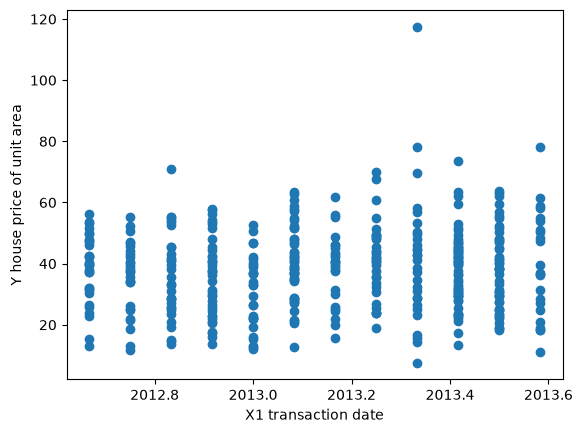

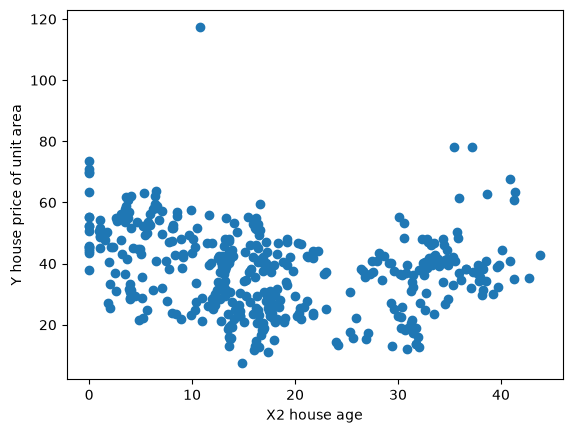

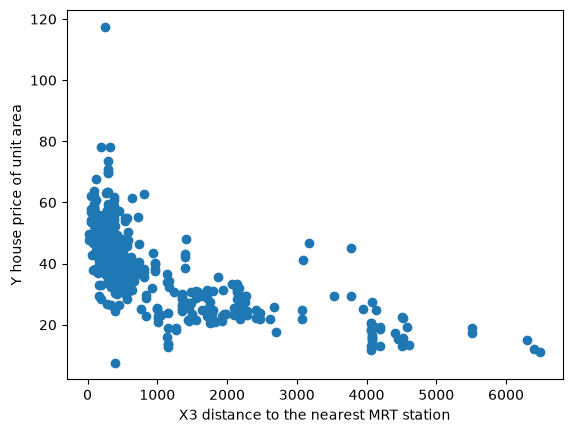

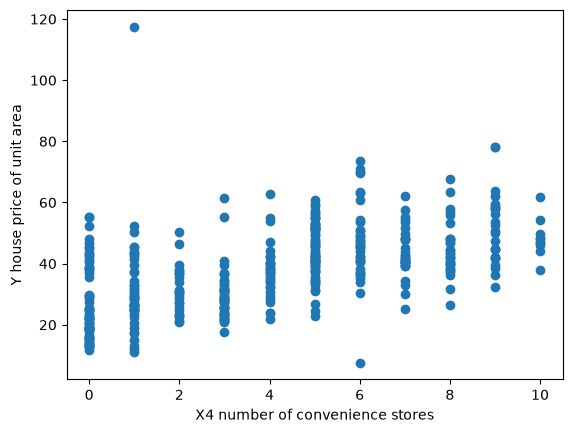

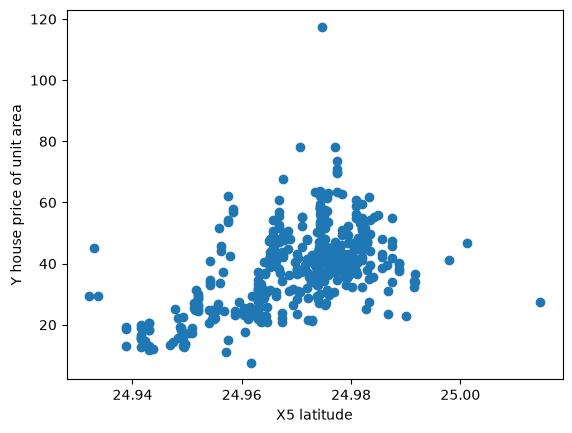

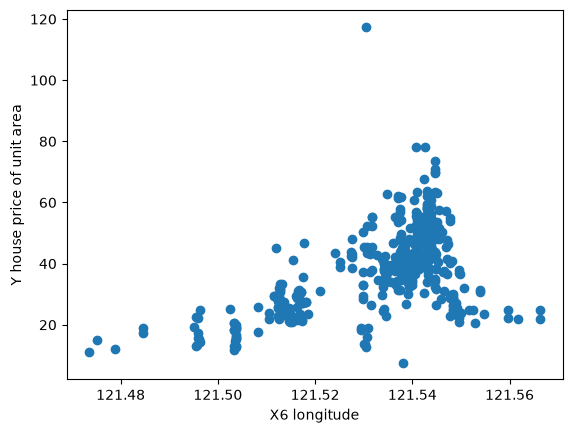

In [5]:
import matplotlib.pyplot as plt

for col in X.columns:
    plt.scatter(X[col], y)
    plt.xlabel(col)
    plt.ylabel('Y house price of unit area')
    plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=123)

In [7]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

In [8]:
X_train

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,0.945014,0.008392,-0.067556,-1.392631,-0.524868,1.017443
1,-0.246786,-0.468570,0.219898,-1.049182,-1.415896,0.970115
2,1.241180,-1.153661,0.840932,-0.362284,-0.529724,-1.336628
3,0.052948,-0.095672,0.951876,-0.362284,-0.864770,-1.288004
4,-0.839118,-1.327102,0.295361,-1.049182,-1.483876,1.007718
...,...,...,...,...,...,...
305,1.241180,-1.153661,0.840932,-0.362284,-0.529724,-1.336628
306,0.945014,-0.078328,-0.624844,0.324615,1.011162,0.649842
307,-0.542952,-0.381849,-0.705185,-1.049182,0.351592,-0.236419
308,-0.542952,-0.087000,1.931310,-1.392631,-3.032046,-1.133702


In [9]:
X_test

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,-0.839118,1.517327,-0.703168,1.354963,0.609755,0.626502
1,0.645280,-0.078328,-0.624844,0.324615,1.011162,0.649842
2,0.052948,-0.355833,-0.261372,-0.705733,0.337834,1.040782
3,-1.138852,-0.399193,-0.718875,-1.049182,0.337834,-0.234474
4,1.241180,-1.049596,-0.544975,0.324615,0.795891,0.583064
...,...,...,...,...,...,...
99,1.241180,-1.144989,-0.606249,0.324615,-1.102701,0.395698
100,1.241180,-0.312473,-0.655369,1.011513,-0.281272,0.616777
101,-1.731183,1.491311,-0.361242,1.011513,0.792654,0.192124
102,-1.731183,-0.156376,-0.209415,-0.018834,0.754618,0.076722


## Modeling

## Linear regression model (Riikka)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 1.38,-3.12,-6.02, 3.12, 2.77,-0.47]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['X1 transaction date','X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores','X5 latitude','X6 longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,38.06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [11]:
b0 = model.intercept_ # note the underscore!
b1 = model.coef_ # returns a list containing a single element

print("Intercept: %.2f" % b0)

for b, name in zip(b1, model.feature_names_in_):
    print(name + ", Coefficient: %.4f" % b)

Intercept: 38.06
X1 transaction date, Coefficient: 1.3819
X2 house age, Coefficient: -3.1150
X3 distance to the nearest MRT station, Coefficient: -6.0160
X4 number of convenience stores, Coefficient: 3.1183
X5 latitude, Coefficient: 2.7696
X6 longitude, Coefficient: -0.4677


intercept on todella iso, se rikkoo kuvaajat.
tarvitaan skaalaus.
X:n muuttujat vaihtelevat paljon (ne ovat eri kokoisia), joten ei ole järkevää verrata keskenään

X1 transaction date 1.3819480897824


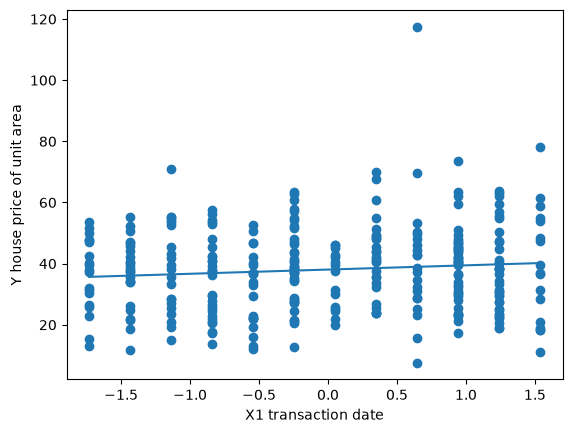

X2 house age -3.115046888441169


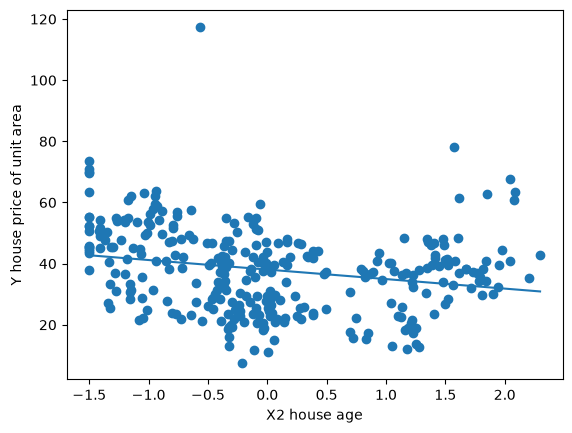

X3 distance to the nearest MRT station -6.0159619098780865


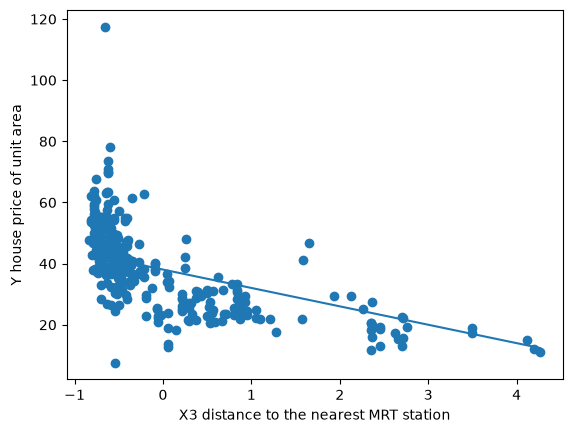

X4 number of convenience stores 3.1183247967942473


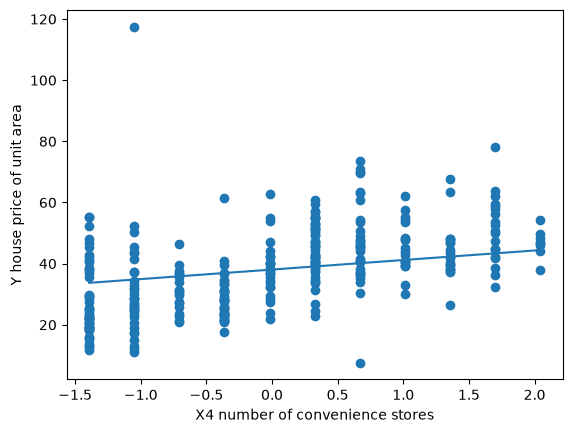

X5 latitude 2.76958509910535


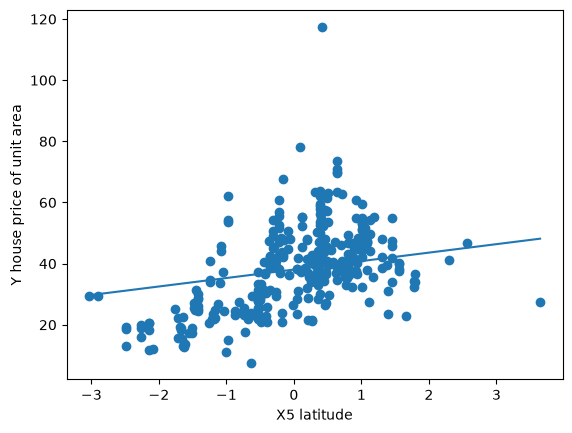

X6 longitude -0.4676966941913359


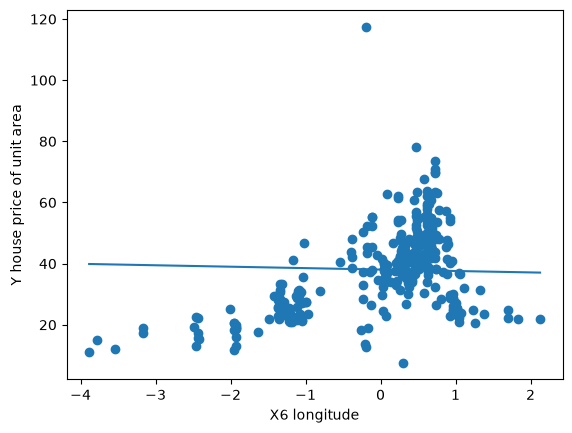

In [12]:
import numpy as np

for col, b in zip(X_train.columns, b1):
    print(col, b)
    
    xs = np.linspace(X_train[col].min(), X_train[col].max())
    ys = b0 + b * xs
    plt.plot(xs, ys)
    plt.scatter(X_train[col], y_train)
    plt.xlabel(col)
    plt.ylabel('Y house price of unit area')
    plt.show()

In [13]:
from sklearn.metrics import mean_absolute_error

preds = model.predict(X_test)
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, preds))

Mean absolute error: 5.14


train vs prediction ero on 5.14

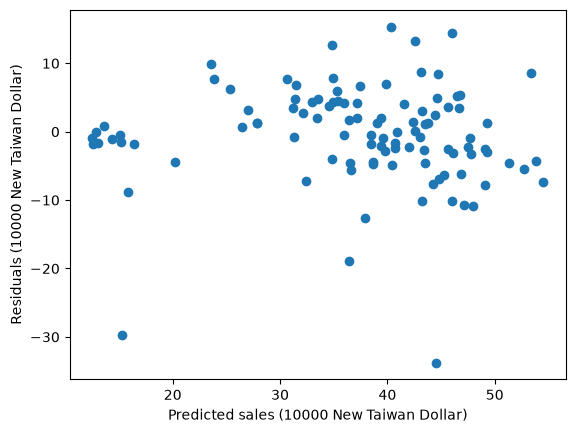

In [14]:
plt.scatter(preds, preds - y_test)
plt.xlabel('Predicted sales (10000 New Taiwan Dollar)')
plt.ylabel('Residuals (10000 New Taiwan Dollar)')
plt.show()

kuvaaja näyttää hyvältä

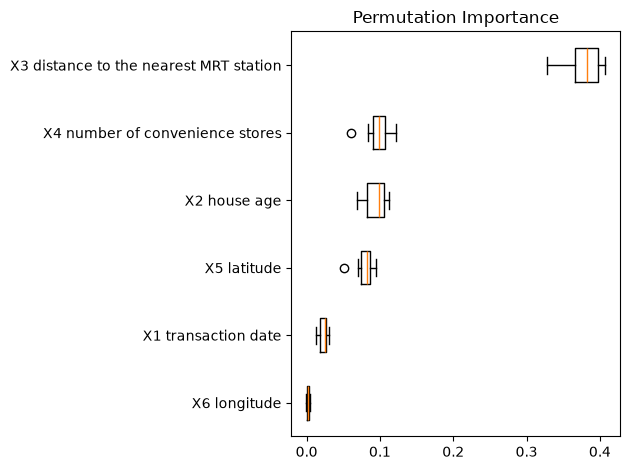

In [15]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=0, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots()
ax.boxplot(result.importances[sorted_idx].T, orientation='horizontal', tick_labels=X.columns[sorted_idx])
ax.set_title("Permutation Importance")
fig.tight_layout()
plt.show()

perustele tulokset, X3 tärkein

## Logistic regression model (Nur)

In [16]:
import numpy as np

mean = y_train.mean()
print(mean)

y_train_b = (y_train > mean).astype(int)
y_test_b = (y_test > mean).astype(int)

38.0641935483871


In [19]:
from sklearn.linear_model import LogisticRegression

reg_model = LogisticRegression(solver='lbfgs')
reg_model.fit(X_train, y_train_b)

print("Coefficients: ", reg_model.coef_)
print("Intercept: ", reg_model.intercept_)

Coefficients:  [[ 0.34245483 -0.7294161  -2.42400942  0.62318646  1.07447641  0.26783573]]
Intercept:  [-0.77409722]


Accuracy: 0.81
Confusion Matrix:
 [[38 10]
 [10 46]]


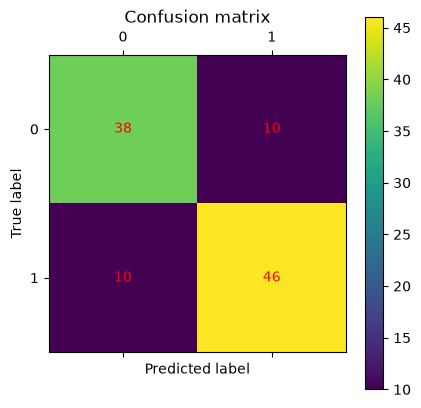

In [20]:
from sklearn.metrics import accuracy_score

preds = reg_model.predict(X_test)

cm = confusion_matrix(y_test_b, preds)
accuracy = accuracy_score(y_test_b, preds)

print("Accuracy: %0.2f" % accuracy)
print("Confusion Matrix:\n", cm)

# visualize confusion matrix
plt.matshow(cm)
plt.title('Confusion matrix')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')

# include counts
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='red')
plt.show()

0 alle keskiarvon (mean), 1 yli keskiarvon (mean) - hinta

The model seems to predict the outcome quite well, with an accuracy of 0.81.

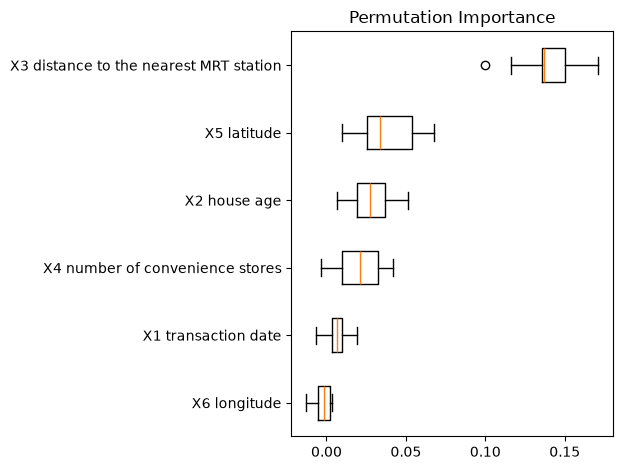

In [21]:
from sklearn.inspection import permutation_importance

result = permutation_importance(reg_model, X_train, y_train_b, n_repeats=10, scoring="accuracy", random_state=0, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots()
ax.boxplot(result.importances[sorted_idx].T, orientation='horizontal', tick_labels=X.columns[sorted_idx])
ax.set_title("Permutation Importance")
fig.tight_layout()
plt.show()

tärkein on X3, vähiten tärkein on X6. selitä pikaisesti tulokset, älä mene syvälle

## Evaluation (Sandra)

## Deployment (Sandra)